# Analyzing continuum-subtracted spectral cubes

In this notebook, we will analyze the outputs of the ```build_cube``` function in notebook #2 using ```species``` to load atmospheric models and computing cross-correlation functions between those models and the data. We will also compute error covariance matrices which can be used in likelihood analyses later in notebook #4.

### Loading and preparing data dictionaries

**This cell must be modified!** Specify the directory where you previously stored the data products. We will analyze the final combined sequence with ```JOINT=True```, although you can set it to False to analyze the individual sequences.

In [43]:
base_path = '/astro/epsig/tutorial/'

JOINT = True

The first step is to load the continuum subtracted data cubes produced by ```build_cube``` and stored in the ```outputs``` subdirectory. The ```hdu2vals``` helper function is used to unpack the fits files and store the ```flux```,```err```,```ra```,```dec```, and ```wave``` arrays into a dictionary indexed by ```target``` and ```detector``` keywords for easy iteration over multiple different sequences, detectors, and targets. Most analysis in this script will iterate over the ```target_list``` iterable which will need to be customized. (Note: The ```JOINT=True``` analysis saves outputs under the first ```seq_num``` in a sequence of multiple sequence nubmers.)

In [44]:
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from multiprocess import Pool
import astropy.units as u
from astropy import constants as const
from astropy.io import fits
from scipy.stats import mode
from scipy.optimize import minimize
from scipy.ndimage import generic_filter
from breads.utils import rotate_coordinates

def hdu2vals(hdu):
    return hdu[0].data,hdu[1].data,hdu[2].data,hdu[3].data,hdu[4].data

if JOINT:
    seq_nums = {'HD 19467 J' : '012'}
else:
    seq_nums = {'HD 19467 1' : '012',
                'HD 19467 2' : '013',
                'HD 19467 3' : '014'}
    
outs = {}
target_list = list(seq_nums.keys())
for target in target_list:
    seq_num = seq_nums[target]
    if JOINT:
        fs = sorted(glob.glob(base_path+'outputs/jw01414{}001_02101_nrs[1,2]_spectral_cube_ish_joint.fits'.format(seq_num)))
        spliti = -5
    else:
        fs = sorted(glob.glob(base_path+'outputs/jw01414{}001_02101_nrs[1,2]_spectral_cube_ish.fits'.format(seq_num)))
        spliti = -4
    o = {}
    for f in fs:
        detector = f.split('_')[spliti]
        hdu = fits.open(f)
        d,e,ra,dec,wave = hdu2vals(hdu)
        o[detector] = {'flux':d,'err':e,'ra':ra,'dec':dec,'wave':wave}
    outs[target] = o

### Loading splines and computing boundaries between variable spacing

Additionally, we will load the spline nodes and compute the divisions where the spacing between the nodes changes. This will be useful later in the computation of the error covariance, since it will depend on the node spacing.

{'nrs1': array([2.859, 2.879, 2.899, 2.919, 2.939, 2.959, 2.979, 2.999, 3.019,
        3.039, 3.059, 3.079, 3.099, 3.119, 3.139, 3.159, 3.189, 3.219,
        3.249, 3.279, 3.309, 3.339, 3.369, 3.399, 3.429, 3.459, 3.499,
        3.539, 3.579, 3.619, 3.659, 3.699, 3.739, 3.779, 3.839, 3.899,
        3.959, 4.019, 4.079, 4.139]),
 'nrs2': array([4.081, 4.141, 4.201, 4.261, 4.321, 4.361, 4.401, 4.441, 4.481,
        4.521, 4.561, 4.601, 4.641, 4.671, 4.701, 4.731, 4.761, 4.791,
        4.821, 4.851, 4.881, 4.911, 4.941, 4.971, 4.991, 5.011, 5.031,
        5.051, 5.071, 5.091, 5.111, 5.131, 5.151, 5.171, 5.191, 5.211,
        5.231, 5.251, 5.271, 5.291]),
 'all': array([2.859, 2.879, 2.899, 2.919, 2.939, 2.959, 2.979, 2.999, 3.019,
        3.039, 3.059, 3.079, 3.099, 3.119, 3.139, 3.159, 3.189, 3.219,
        3.249, 3.279, 3.309, 3.339, 3.369, 3.399, 3.429, 3.459, 3.499,
        3.539, 3.579, 3.619, 3.659, 3.699, 3.739, 3.779, 3.839, 3.899,
        3.959, 4.019, 4.079, 4.141, 4.201, 4.261,

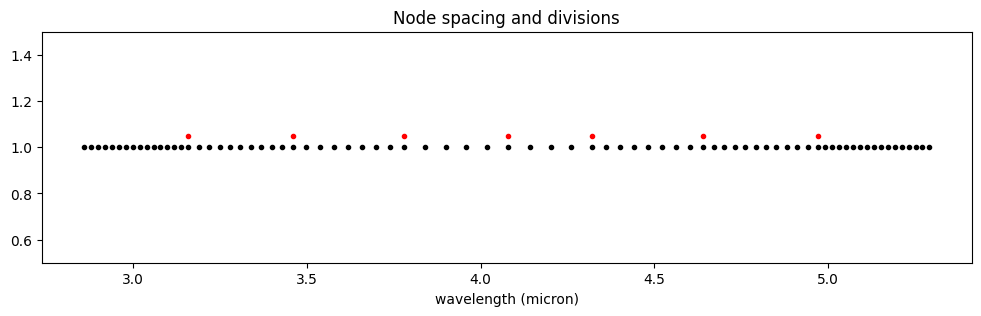

In [45]:
wv_nodes_dict = np.load(base_path+'nonuniform_nodes.npy',allow_pickle=True).item()
wv_nodes_dict['all'] = np.concatenate([wv_nodes_dict['nrs1'][:-1],wv_nodes_dict['nrs2'][1:]])
wv_nodes_dict['divs'] = wv_nodes_dict['all'][np.where(abs(np.diff(np.diff(wv_nodes_dict['all'])))>0.009)[0]+1]
wv_nodes_dict['divs'] = np.concatenate([wv_nodes_dict['divs'][:3],[4.08],wv_nodes_dict['divs'][3:]])

plt.figure(figsize=(12,3))
plt.plot(wv_nodes_dict['all'],np.ones(len(wv_nodes_dict['all'])),'k.')
plt.plot(wv_nodes_dict['divs'],1.05*np.ones(len(wv_nodes_dict['divs'])),'r.')
plt.ylim([.5,1.5])
plt.xlabel('wavelength (micron)')
plt.title('Node spacing and divisions')

wv_nodes_dict

### Configuring species to load atmospheric models

**This cell must be modified!** This notebook relies on using the ```species``` package to load atmospheric models. We need to create a configuration file ```species_config.ini``` in the current working directory to tell the package where to store the model data and database files. Read more (https://species.readthedocs.io/en/latest/configuration.html).

In [46]:
config = '''
[species]
database = /user/amadurowicz/species_database.hdf5
data_folder = /user/amadurowicz/data/
vega_mag = 0.03
'''

with open("species_config.ini", "w") as config_file:
    config_file.write(config)

Now we can load the ```breads.atm_utils.miniRGI``` module which relies on the ```species``` backend for convenient and memory-efficient model access.

In [47]:
from breads.atm_utils import miniRGI
from breads.atm_utils import rprint
from breads.utils import filter_spec_with_spline

### Target parameter inputs 

We need to specify a few different input parameters for the target object, notably the atmospheric model parameters for computing the CCF, and the predicted location of the object (in DeltaRA / DeltaDEC arcsec) for extracting the spectra at the correct position. This cell provides an example for a T-type model with Teff=1100K, log g = 5.0 (cgs), M/H = 0, C/O = 0.458 (solar) and log Kzz = 7 (cgs), and coordinates of dRA = -1318.832 +/- 11.715 mas dDec = -885.588 +/- 14.037 mas, which is taken from http://whereistheplanet.com

In [48]:
templates = {}
#parameters = sonora-elfowl-___, Teff, log g, M/H, C/O  , log Kzz
templates['HD 19467']     = 't',[1100, 5.0  , 0  , 0.458, 7      ]

#whereistheplanet HD 19467 B 1/25/2024 Brandt 2021
#RA Offset = -1315.872 +/- 13.461 mas
#Dec Offset = -885.944 +/- 17.234 mas
predicted_locations = {}
predicted_locations['HD 19467'] = {'ra':-1.315872,
                                   'dec':-.885944,
                                   'raerr':0.013461,
                                   'decerr':0.017234}

### Computing the CCFs

In the following cell, we define the function for computing CCFs on the continuum subtracted spectral cubes and then run it. The ```_ccf_task``` function iterates over position indices (mx, my) which are initialized by ```range(0,N)``` and transformed from 1D vectors into an "outer product" ```op``` using ```meshgrid``` and ```reshape```. The CCF is computing by interpolating the continuum-subtracted synthetic model flux ```hpf``` on a shifting wavelength grid depedning on the ```rv``` parameter, and taking the sum of the product of the shifted model and data ```spec```.

In [49]:
N = 60
mys = range(0,N)
mxs = range(0,N)
op = np.array(np.meshgrid(mys,mxs)).T.reshape(-1,2)
rvs = np.arange(-3000,3000,1)*1e3 # RV range is +/-3000 km/s -> +/- 3e6 m/s
zero_rv_index = len(rvs)//2

def MJy_2_Wm2um(w,f):
    fnu = (f*u.MJy).to(u.W/u.m**2/u.Hz)
    flam = fnu*const.c*1e6/(w * u.um)**2
    return flam.value

def _ccf_task(params):
    my, mx = params
    rprint('{},{}'.format(my,mx))
    
    spec = MJy_2_Wm2um(w,d[:,my,mx])
    
    ccfs = []
    for rv in rvs:
        rvf = (1 + rv/const.c.value)
        rv_wvs = w*rvf
        synflux = np.interp(rv_wvs,mrgi.wavelength,hpf)
        ccf = np.nansum(spec*synflux)
        ccfs.append(ccf)
    return ccfs

ccfs = {}
for target in target_list:

    ##### repackage data #####
    nrs1 = outs[target]['nrs1']
    nrs2 = outs[target]['nrs2']
    d = np.vstack([nrs1['flux'],nrs2['flux']])
    w = np.hstack([nrs1['wave'],nrs2['wave']])
    e = np.vstack([nrs1['err'],nrs2['err']])

    ##### load model and subtract spline #####
    type_str, template_params = templates[target[:-2]]
    mrgi = miniRGI('sonora-elfowl-{}'.format(type_str), wavelength_bounds=[2.5, 5.5], R=2700, load_flag=False, save_flag=False)
    f = mrgi(template_params)[0]
    hpf,_ = filter_spec_with_spline(mrgi.wavelength,f,x_nodes=wv_nodes_dict['all'])

    ##### compute CCF (w, d, hpf) _{ my, mx } #####
    with Pool() as pool:
        mapout = pool.map(_ccf_task,op)
    print('')
    all_ccfs = np.ones((N,N,len(rvs)))*np.nan
    for i,o in enumerate(mapout):
        _my,_mx = np.unravel_index(i,(N,N))
        all_ccfs[_my,_mx,:] = o
    ccfs[target] = all_ccfs

miniRGI model: miniRGI_sonora-elfowl-t_2.5-5.5um_R2700,
parameter bounds: {'teff': (575.0, 1200.0), 'logg': (3.0, 5.5), 'feh': (-1.0, 1.0), 'c_o_ratio': (0.229, 1.145), 'log_kzz': (2.0, 9.0)}
restricting wavelengths: 2.5 to 5.5 um
Spectral Resolution: 2700
broadening... 1/1 
58,14


### Transforming coordinates predictions from sky (RA/DEC) to IFU X and Y

(Only necessary for ```JOINT=False```) The following cell transforms the input coordinates specified by the user into the IFU-aligned coordinate system. Essentially this is a rotation by the angle ```east2V2_deg```, including a bootstrap to compute its standard deviation (purely for visulization). The computed coordinates ```ifuX``` and ```ifuY``` are used to select the position of the planet in the spectral cube to extract.

In [50]:
### COMPUTE PREDICTED LOCATION ###

predicted_ifuX = {}
predicted_ifuY = {}

for target in target_list:
    loc_d = predicted_locations[target[:-2]]
    skyra = loc_d['ra']
    skydec = loc_d['dec']
    skyra_err = loc_d['raerr']
    skydec_err = loc_d['decerr']

    files = glob.glob(base_path+'data/G395H_stage2_cleaned/jw01414'+seq_nums[target]+'*cal.fits')
    angs = []
    for f in files:
        hdu = fits.open(f)
        east2V2_deg = -(float(hdu[1].header["ROLL_REF"]) + float(hdu[1].header["V3I_YANG"]))
        angs.append(east2V2_deg)
    avg_east2V2_deg = np.mean(angs)

    N = 1000
    ra_distribution = np.random.normal(loc=skyra, scale=skyra_err, size=N)
    dec_distribution = np.random.normal(loc=skydec, scale=skydec_err, size=N)
    
    Xs = []
    Ys = []
    for ind in range(N):
        ra = ra_distribution[ind]
        dec = dec_distribution[ind]
        ifuX, ifuY = rotate_coordinates(ra, dec, avg_east2V2_deg, flipx=False)
        Xs.append(ifuX)
        Ys.append(ifuY)
    meanX = np.mean(Xs)
    meanY = np.mean(Ys)
    stdX = np.std(Xs)
    stdY = np.std(Ys)
    print('target: {} ifuX: {} +/- {}, ifuY: {} +/- {}'.format(target, 
                                                               np.round(meanX,3),
                                                               np.round(stdX,3),
                                                               np.round(meanY,3),
                                                               np.round(stdY,3)))
    predicted_ifuX[target] = meanX,stdX
    predicted_ifuY[target] = meanY,stdY

target: HD 19467 J ifuX: 0.622 +/- 0.014, ifuY: 1.459 +/- 0.016


### Visualizing the CCF / detection map

The following cell plots the 1D CCF (as a function of RV) and the 2D CCF (as a function of IFU/sky coordinates) both of which can be considered to be part of the "detection map in phase space" for the target object. It also computes the significance of the detection (1) relative to the "wings" of the CCF (i.e. where RV > 200 km/s) which is almost never >10 sigma due to the model autocorrelation and (2) relative to the "noise annulus". This second detection sigma is much more accurate since it does not need to account for model auto-correlation. The noise spectra are also extracted in this step and save for later estimation of the empirical error covaraince.

HD 19467 J
detected: 15.143353146917098 sigma (relative to wings, i.e. RV > |200000.0| m/s )
CCF peak at RV index: 3002, velocity: 2000.0


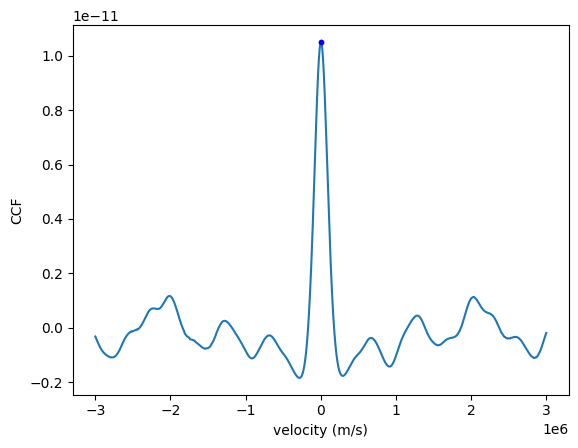

delta_phi = 9.66320872406151 deg
detected: 168.66449549811682 sigma (relative to annulus)


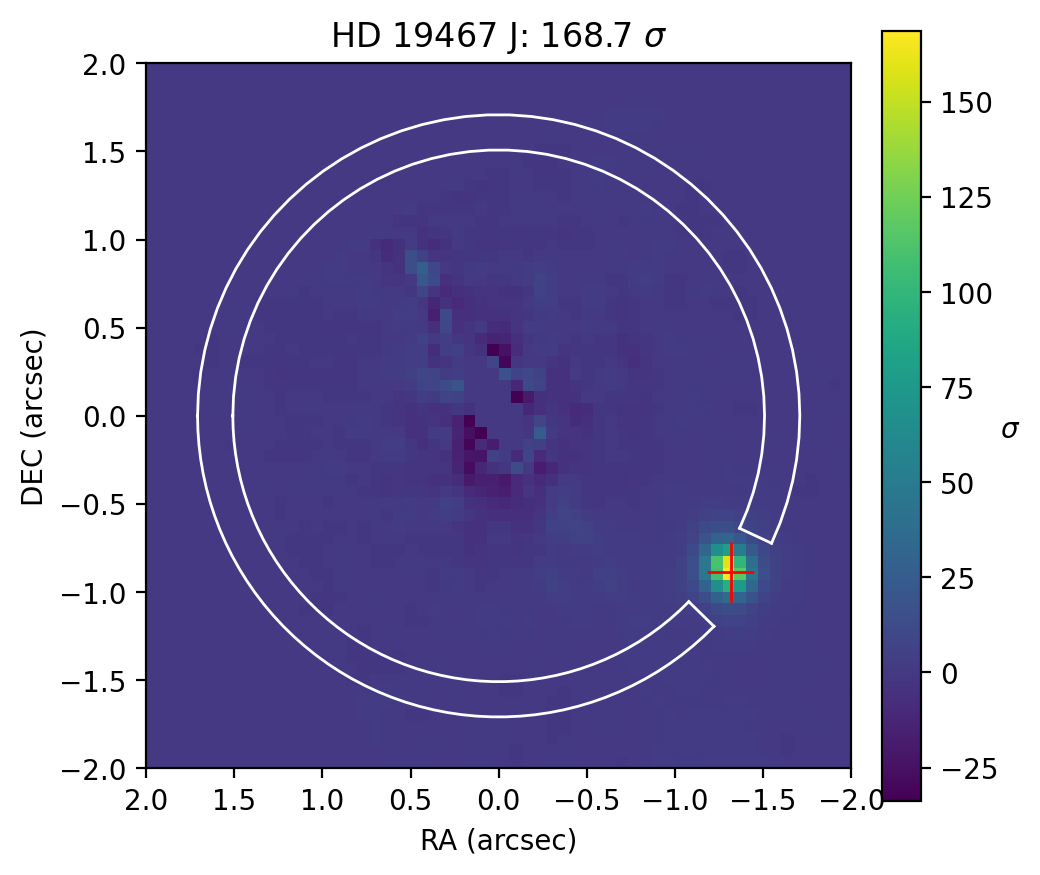

In [51]:
def annular_anti_slice(inner,outer,phi0,phi1,color='k'):
    '''helper function for plotting noise annulus'''
    phi0,phi1 = (90-phi1)%360,(90-phi0)%360
    theta = np.concatenate([np.linspace(0,phi0),[np.nan],np.linspace(phi1,360)])
    x3, y3 = inner*np.cos(np.deg2rad(theta)),inner*np.sin(np.deg2rad(theta))
    x4, y4 = outer*np.cos(np.deg2rad(theta)),outer*np.sin(np.deg2rad(theta))
    rho = np.linspace(inner,outer)
    x1, y1 = rho*np.cos(np.deg2rad(phi0)),rho*np.sin(np.deg2rad(phi0))
    x2, y2 = rho*np.cos(np.deg2rad(phi1)),rho*np.sin(np.deg2rad(phi1))
    plt.plot(x1,y1,color=color,linewidth=1)
    plt.plot(x2,y2,color=color,linewidth=1)
    plt.plot(x3,y3,color=color,linewidth=1)
    plt.plot(x4,y4,color=color,linewidth=1)

speckle_spectra = {}
best_RVs = {}
det_sigs = {}

for target in target_list[:]:
    print(target)
    all_ccfs = ccfs[target]

    ##### SELECT SPATIAL INDICES (mx, my) #####
    ra, dec = outs[target]['nrs2']['ra'],outs[target]['nrs2']['dec']
    if JOINT:
        loc_d = predicted_locations[target[:-2]]
        skyra = loc_d['ra']
        skydec = loc_d['dec']
        mx,my = np.argmin(abs(skyra-ra[0,:])),np.argmin(abs(skydec-dec[:,0]))
    else:
        meanX, stdX = predicted_ifuX[target]
        meanY, stdY = predicted_ifuY[target]
        mx,my = np.argmin(abs(meanX-ra[0,:])),np.argmin(abs(meanY-dec[:,0]))

    ##### Detection significance relative to CCF wings #####
    cutv = 200e3
    lr = np.where(rvs < -cutv)[0][-1]
    rr = np.where(rvs > cutv)[0][0]
    #print(lr,rr)
    std = np.std(np.concatenate([all_ccfs[my,mx,:lr],all_ccfs[my,mx,rr:]]))
    det_sig1 = all_ccfs[my,mx,zero_rv_index]/std
    print(r'detected: {} sigma (relative to wings, i.e. RV > |{}| m/s )'.format(det_sig1, cutv))

    #### PLOT CCF (RV) #####
    rv_bfi = np.argmax(all_ccfs[my,mx,:])
    best_RVs[target] = rvs[rv_bfi]
    print('CCF peak at RV index: {}, velocity: {}'.format(rv_bfi,rvs[rv_bfi]))
    plt.plot(rvs,all_ccfs[my,mx,:])
    plt.plot(rvs[rv_bfi],all_ccfs[my,mx,rv_bfi],'r.')
    plt.plot(rvs[zero_rv_index],all_ccfs[my,mx,zero_rv_index],'b.')
    plt.xlabel('velocity (m/s)')
    plt.ylabel('CCF')
    plt.show()

    ### Significance relative to annulus ###
    p_ra, p_dec = ra[my,mx], dec[my,mx]
    p_rho = np.sqrt(p_ra**2 + p_dec**2)
    delta_rho = 0.1
    inner = p_rho-delta_rho
    outer = p_rho+delta_rho
    star_radius = np.sqrt((ra)**2 + (dec)**2)
    star_PA = (360+90-np.rad2deg(np.arctan2(dec,ra)))%360
    phi_p = (360+90-np.rad2deg(np.arctan2(p_dec,p_ra)))%360
    arcsec_per_px = (np.mean(np.gradient(dec)[0])+np.mean(np.gradient(ra)[1]))/2
    Npx_circum = 2*np.pi*p_rho/(arcsec_per_px)
    Npx_elim = 4
    delta_phi = Npx_elim / Npx_circum * 360
    print('delta_phi = {} deg'.format(delta_phi))
    phi0, phi1 = phi_p-delta_phi, phi_p+delta_phi
    annulus = np.logical_and((star_radius < outer),(star_radius > inner))
    PA_slice = np.logical_not(np.logical_and((star_PA > phi0),(star_PA < phi1)))
    cut_annulus = np.logical_and(annulus,PA_slice)
    annular_std = np.std(all_ccfs[cut_annulus,zero_rv_index])
    
    det_sig2 = all_ccfs[my,mx,zero_rv_index]/annular_std
    det_sigs[target] = det_sig2
    print(r'detected: {} sigma (relative to annulus)'.format(det_sig2))

    ##### Extract speckle_spectra inside annulus #####
    speckle_spectra_nrs1 = outs[target]['nrs1']['flux'][:,cut_annulus]
    speckle_spectra_nrs2 = outs[target]['nrs2']['flux'][:,cut_annulus]
    speckle_spectra[target] = {'nrs1':speckle_spectra_nrs1,'nrs2':speckle_spectra_nrs2}

    ##### PLOT CCF IMAGE / PREDICTED POSITION / NOISE ANNULUS #####
    dramin, dramax, ddecmin, ddecmax = np.min(ra),np.max(ra),np.min(dec),np.max(dec) 
    
    plt.figure(figsize=(5,5),dpi=200)
    annular_anti_slice(inner,outer,phi0,phi1,color='w')
    
    plt.imshow(all_ccfs[:,:,zero_rv_index]/annular_std,
               origin='lower',
               vmin=-det_sig2/5.,vmax=det_sig2,
               extent=[dramin, dramax, ddecmin, ddecmax],
               aspect='equal')
    plt.xlim([dramin, dramax])
    plt.ylim([ddecmin, ddecmax])
    #plt.plot(ra[my,mx], dec[my,mx],'r*',markersize=1)
    cbar = plt.colorbar(fraction=0.05, pad=0.04)
    cbar.set_label(r'$\sigma$',rotation=0)
    
    if JOINT:
        plt.errorbar(skyra,skydec,xerr=skyra_err*10,yerr=skydec_err*10,color='r',markersize=2,linewidth=1)
        plt.xlabel('RA (arcsec)')
        plt.ylabel('DEC (arcsec)')
        plt.xlim([dramax,dramin])
    else:
        plt.errorbar(meanX,meanY,xerr=stdX*10,yerr=stdY*10,color='r',markersize=2,linewidth=1)
        plt.xlabel('IFU x (arcsec)')
        plt.ylabel('IFU y (arcsec)')
    plt.title(r'{}: {} $\sigma$'.format(target,np.round(det_sig2,1)))
    plt.show()

np.save(base_path+'det_sigs.npy',det_sigs)
np.save(base_path+'best_RVs.npy',best_RVs)

### Extracting spectra at the predicted location

Using the previously computed detector locations ```ifuX``` and ```ifuY``` we extract the 1D continuum-subtracted spectra at this user specified position by obtaining the closest indices in the ```ra``` and ```dec``` vectors saved during ```build_cube```. If ```JOINT=True``` then we use the sky coordinates instead of the IFU coordinates for consistency. The resulting 1D spectra are saved into the ```products``` dictionary in units of W/m^2/micron.

_________
HD 19467 J


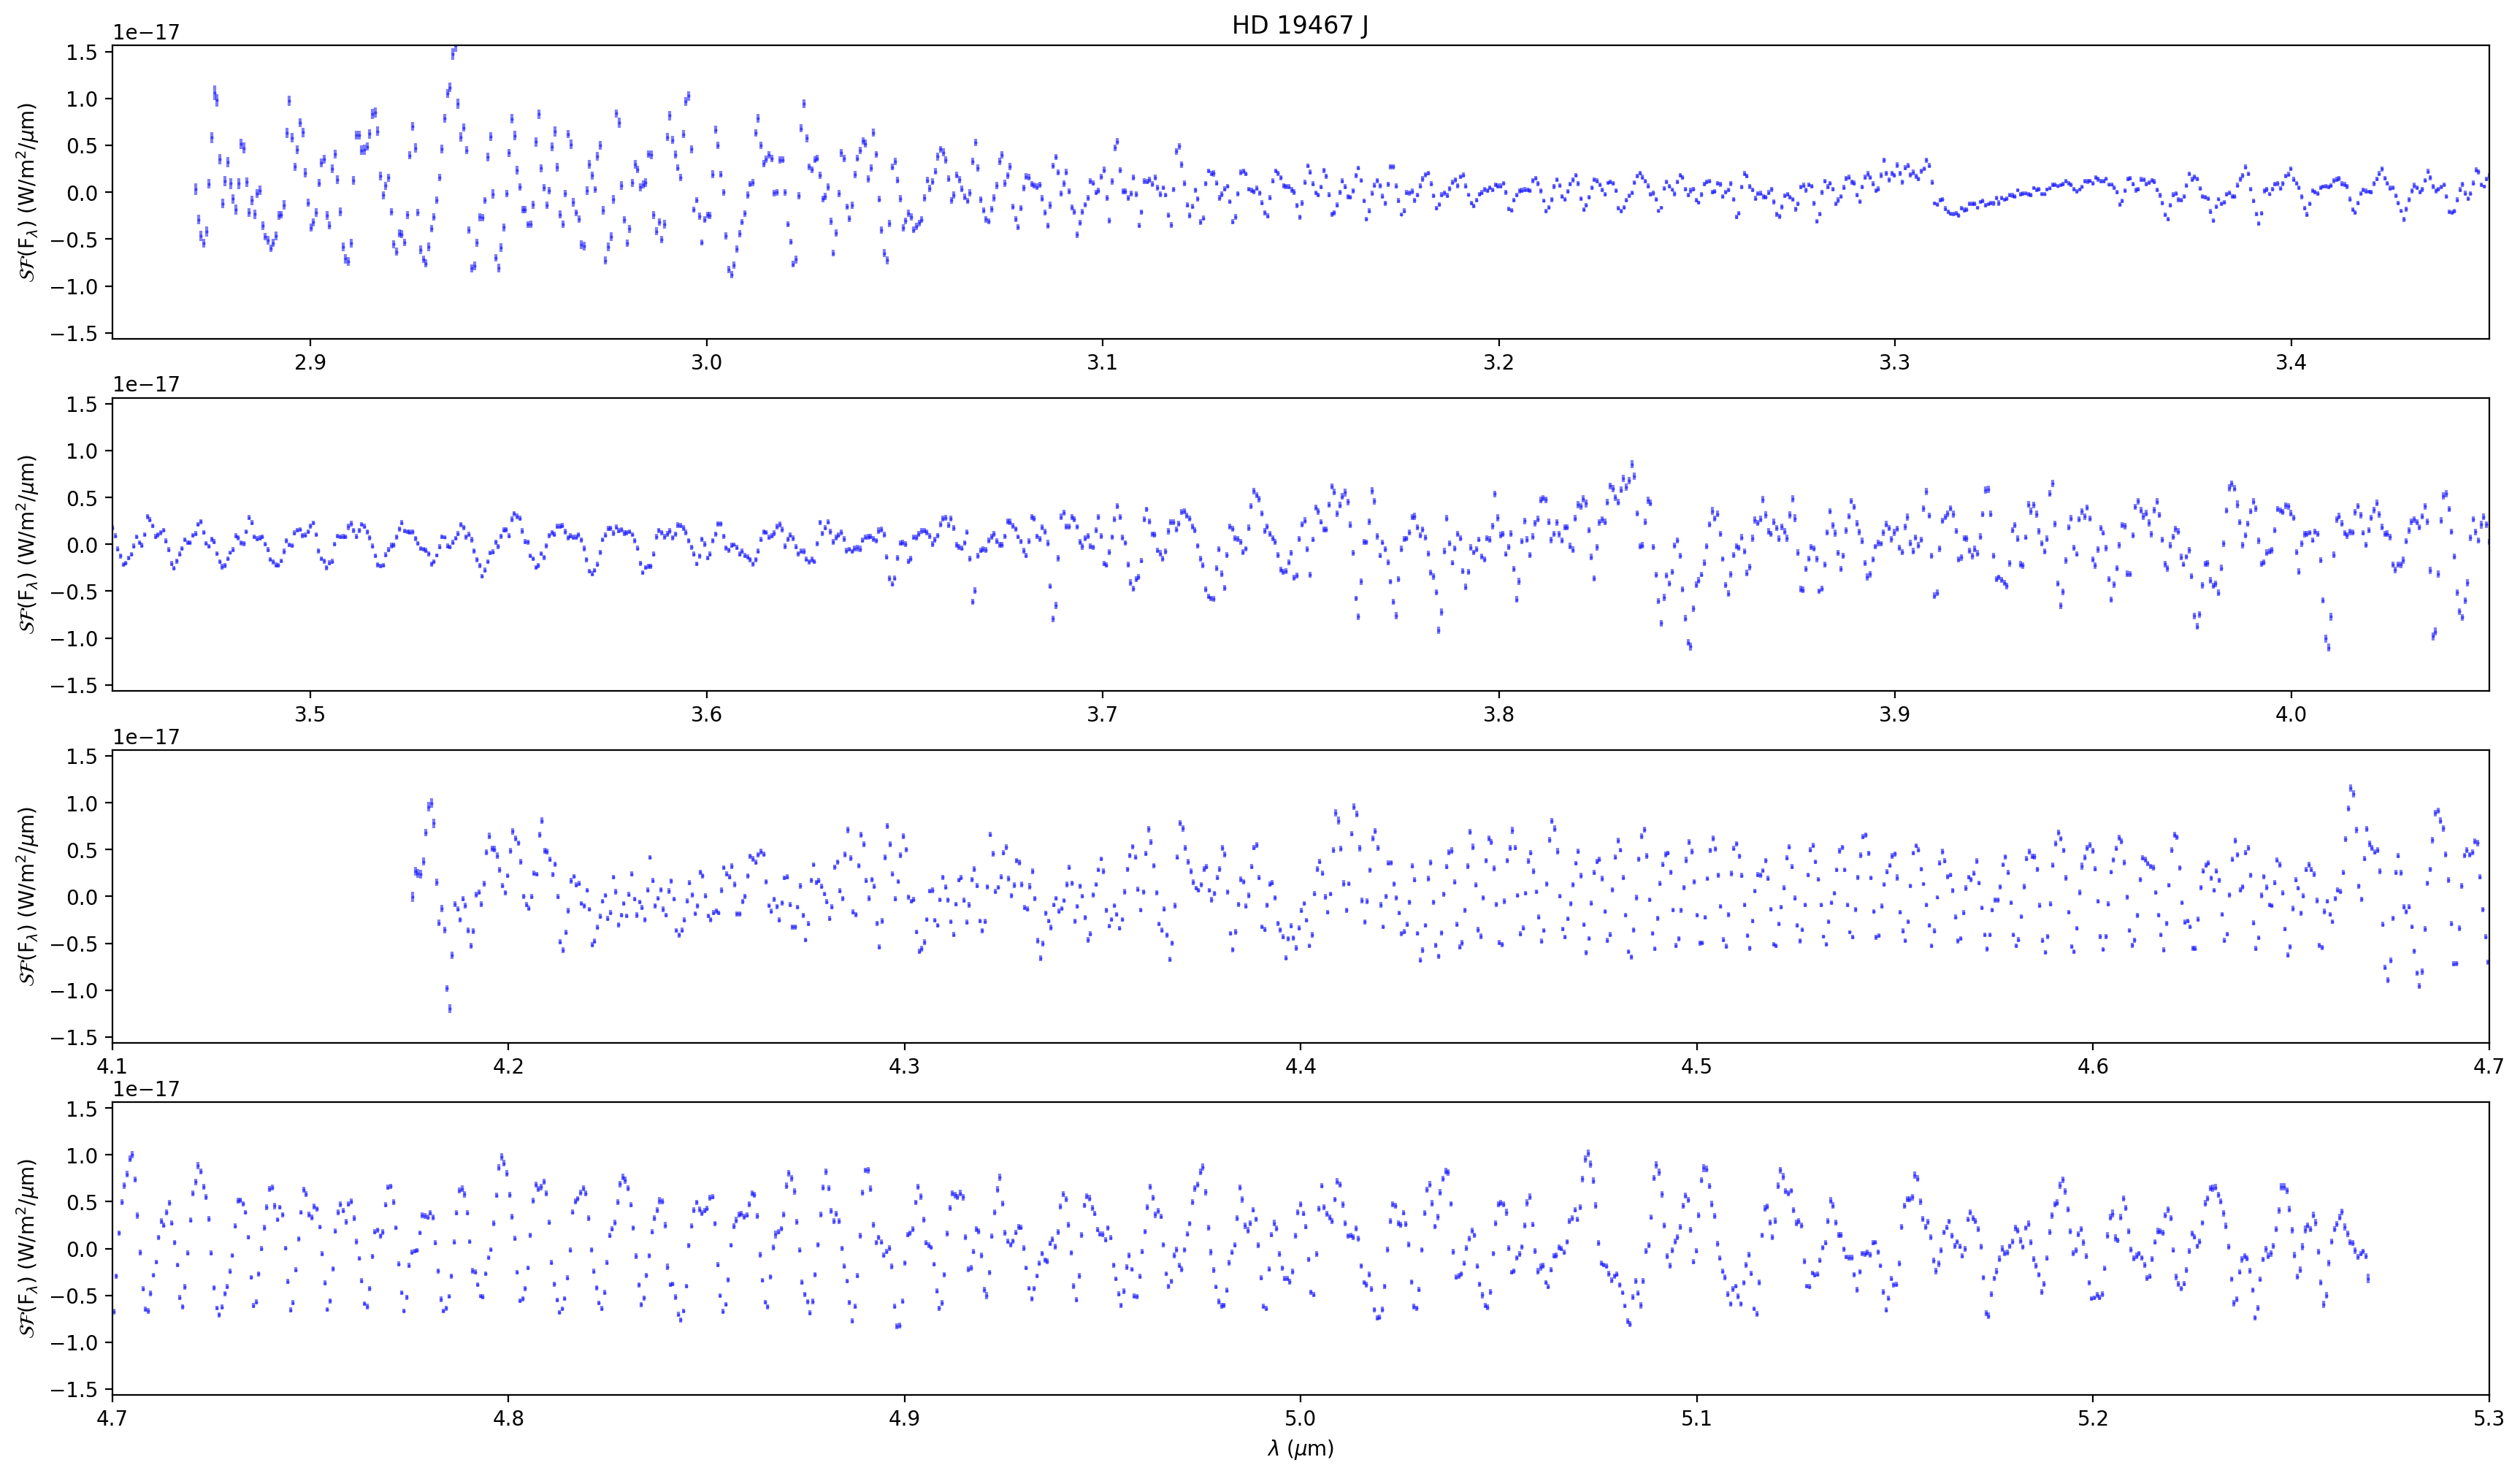

In [52]:
colors = ['blue','orange','red']

products = {}
for j,target in enumerate(target_list):
    fig,ax = plt.subplots(4,1,figsize=(21,12),dpi=200)
    print('_________')
    print(target)

    ##### REPACKAGE DATA #####
    nrs1 = outs[target]['nrs1']
    nrs2 = outs[target]['nrs2']
    d = np.vstack([nrs1['flux'],nrs2['flux']])
    w = np.hstack([nrs1['wave'],nrs2['wave']])
    e = np.vstack([nrs1['err'],nrs2['err']])
    ra, dec = outs[target]['nrs2']['ra'],outs[target]['nrs2']['dec']

    ##### SELECT SPATIAL INDICES (mx, my) #####
    if JOINT:
        loc_d = predicted_locations[target[:-2]]
        skyra = loc_d['ra']
        skydec = loc_d['dec']
        mx,my = np.argmin(abs(skyra-ra[0,:])),np.argmin(abs(skydec-dec[:,0]))
    else:
        meanX, stdX = predicted_ifuX[target]
        meanY, stdY = predicted_ifuY[target]
        mx,my = np.argmin(abs(meanX-ra[0,:])),np.argmin(abs(meanY-dec[:,0]))

    ##### EXTRACT AT POSITION ####
    spec = d[:,my,mx]
    err = e[:,my,mx]

    #### CONVERT UNITS #####
    spec_ = MJy_2_Wm2um(w,spec)
    err_ = MJy_2_Wm2um(w,err)

    ##### SAVE OUTPUTS #####
    obj = {}
    obj['wave'] = w
    obj['spec'] = spec_
    obj['err'] = err_
    obj['valid'] = np.logical_not(np.isnan(spec_))
    products[target] = obj

    #### PLOTTING ####
    for a in ax:
        a.errorbar(w,spec_,err_,color=colors[j],linestyle='none',alpha=.5,marker='.',markersize=1)
        a.set_ylabel(r'$\mathcal{SF}($F$_\lambda$) (W/m$^2$/$\mu$m)')
    
    ax[0].set_xlim([2.85,3.45])
    ax[1].set_xlim([3.45,4.05])
    ax[2].set_xlim([4.1,4.7])
    ax[3].set_xlim([4.7,5.3])

    ymax = np.nanmax(spec_)
    ax[0].set_ylim([-ymax,ymax])
    ax[1].set_ylim([-ymax,ymax])
    ax[2].set_ylim([-ymax,ymax])
    ax[3].set_ylim([-ymax,ymax])
    
    ax[3].set_xlabel(r'$\lambda$ ($\mu$m)')
    ax[0].set_title('{}'.format(target))
    plt.show()

### Computing Covariance Matrices

The following two cells estimate the empirical error covariance from the "noise spectra" which are regions of empty sky extracted from the ```cut_annnulus``` region defined previously (essentially this is the region which has the same separation but different position angles to the extracted target). We assume the correlations in the residual noise can be described by a function f(delta lambda) which is unique to each region of constant node spacing -- since the residuals oscillate on the spectral scale of the spline model used to subtact the continuum. This method is similar to what is done in Appendix E of Ruffio et al 2024 (https://iopscience.iop.org/article/10.3847/1538-3881/ad5281) for the covariance estimation of RDI spectra, although the form of the correlation profile is different.

In [53]:
##### function for computing correlation profiles #####
def calc_corr(normalized_speckles,wave):
    correlations = []
    stds = []
    Nsamps = []
    for idelt in range(len(wave)):
        if idelt == 0:
            left_speckles = normalized_speckles[:]
            right_speckles = normalized_speckles[:]
        else: 
            left_speckles = normalized_speckles[:-idelt]
            right_speckles = normalized_speckles[idelt:]
        prod = left_speckles*right_speckles
        mean_correlation = np.nanmean(prod)
        std_correlation = np.nanstd(prod)
        Nsamples = left_speckles.shape[0]*left_speckles.shape[1]
        correlations.append(mean_correlation)
        stds.append(std_correlation)
        Nsamps.append(Nsamples)
    correlations = np.array(correlations)
    mean_error = np.array(stds)/np.sqrt(np.array(Nsamps))
    return correlations, mean_error

#### defining the wavelength boundaries of the uniform spline regions #####
regions = []
regions.append((outs[target]['nrs1']['wave'][0],wv_nodes_dict['divs'][0]))
for i in range(len(wv_nodes_dict['divs'])-1):
    regions.append((wv_nodes_dict['divs'][i],wv_nodes_dict['divs'][i+1]))
regions.append((wv_nodes_dict['divs'][-1],outs[target]['nrs2']['wave'][-1]))
regions

[(2.859503984451294, 3.159),
 (3.159, 3.459),
 (3.459, 3.779),
 (3.779, 4.08),
 (4.08, 4.321),
 (4.321, 4.641),
 (4.641, 4.971),
 (4.971, 5.278817176818848)]

HD 19467 J


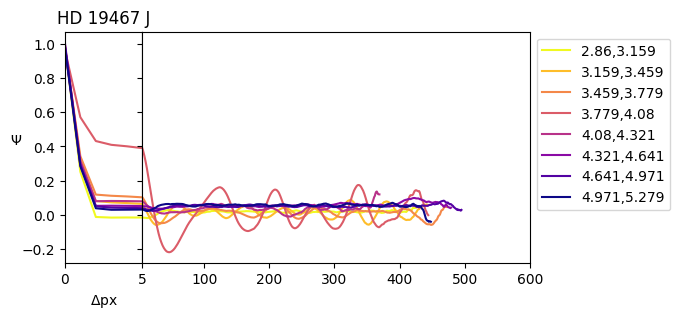

In [54]:
corrs = {}
cov_ms = {}
inv_ms = {}
stds = {}
valids = {}
samples = {}
waves = {}
speckles = {}
for target in target_list:
    print(target)
    
    #load wavelengths, speckle spectra, concatenate, retain wavelengths with at least 2 finite pixels (needed for std)
    nrs1w = outs[target]['nrs1']['wave']
    nrs2w = outs[target]['nrs2']['wave']
    ss1 = speckle_spectra[target]['nrs1']
    ss2 = speckle_spectra[target]['nrs2']
    wave = np.concatenate([nrs1w,nrs2w])
    ss = np.concatenate([ss1,ss2])
    for _i in range(ss.shape[1]):
        ss[:,_i] = MJy_2_Wm2um(wave,ss[:,_i])

    N = len(wave)
    valid = np.zeros(N)
    ssv =  np.zeros(ss.shape)
    std_wave = np.zeros(N)
    cov_m = np.zeros((N,N))
    corr = []

    # chunk based on regions
    for region in regions:
        w1, w2 = region
        wbool = np.logical_and(wave>=w1,wave<w2)
        _wave = wave[wbool]
        _ss = ss[wbool]

        _valid = np.sum(np.isfinite(_ss),axis=1)>=2
        _wave = _wave[_valid]
        _ssv = _ss[_valid,:]
    
        # normalize speckle spectra with std over wavelength
        wave1shape = (_ssv.shape[0],1)
        _std_wave = np.nanstd(_ssv,axis=1)
        std_wave2d = _std_wave.reshape(wave1shape)
        normalized_speckles = _ssv/std_wave2d
    
        # calculate correlation profile and normalize
        correlations, mean_error = calc_corr(normalized_speckles,_wave)
        correlations /= correlations[0]
    
        # separate correlations into large (>3 dpx) and small (<3 dpx) components
        small_c = np.zeros(len(correlations))
        small_c[0:3] = correlations[0:3]-correlations[3]
        large_c = np.copy(correlations)
        large_c[0:3] = correlations[3]
        
        # smooth large component with 20 pixel running mean
        large_c = generic_filter(large_c,np.nanmean,size=20)
    
        # apply correlation profile onto outer product of dpx distance
        indices = np.arange(len(correlations))
        corr_matrix_distances = np.abs(indices[:,None]-indices[None,:])
        _corr = small_c + large_c
        corr_m = np.interp(corr_matrix_distances,indices,_corr)
        _cov_m = corr_m*(_std_wave[:,None]*_std_wave[None,:])

        corr.append(_corr)
        newb = np.copy(wbool)
        newb[wbool] = wbool[wbool]*_valid
        
        valid[wbool] = _valid
        ssv[newb] = _ssv
        std_wave[newb] = _std_wave
        cov_m[np.outer(newb,newb)] = _cov_m.reshape(-1)

    # generate samples and invert covariance matrix
    valid = valid.astype(bool)
    cov_valid = cov_m[valid,:][:,valid]
    
    sample = np.random.multivariate_normal(np.zeros(cov_valid.shape[0]),cov_valid,size=10)
    cov_inv = np.linalg.pinv(cov_valid)

    waves[target]    = wave
    speckles[target] = ssv
    valids[target]   = valid
    stds[target]     = std_wave
    corrs[target]    = corr
    cov_ms[target]   = cov_m
    inv_ms[target]   = cov_inv
    samples[target]  = sample

##### plot 1D correlation profiles #####

cmap = mpl.colormaps['plasma_r']
colors = cmap(np.linspace(0,1,8))

for i,target in enumerate(target_list):
    fig,ax = plt.subplots(1,2,figsize=(6,3),sharex='col',sharey=True,gridspec_kw={'width_ratios':[1,5]})

    corr = corrs[target]
    leg = []
    for j,c in enumerate(corr):
        ax[0].plot(c,color=colors[j])
        ax[1].plot(c,color=colors[j])
        leg.append('{},{}'.format(np.round(regions[j][0],3),np.round(regions[j][1],3)))
    ax[0].set_title(target)
    ax[0].set_xlim([0,5])
    ax[1].set_xlim([5,600])
    ax[1].legend(leg,bbox_to_anchor=[1,1,0,0],loc='upper left')
    plt.subplots_adjust(wspace=0)
    ax[0].set_xlabel(r'$\Delta$px')
    ax[0].set_ylabel(r'$\Psi$',rotation=0)
    plt.show()

##### save 2D covariance matrices #####

for target in target_list:
    obj = products[target]
    v1 = obj['valid']
    v2 = valids[target]
    v1w2 = v1[v2]
    valid = np.logical_and(v1,v2)
    
    obj['valid'] = valid
    obj['Cov'] = cov_ms[target][valid,:][:,valid]
    obj['Cinv'] = inv_ms[target][v1w2,:][:,v1w2]

    prod_path = base_path+'products/'
    if not os.path.exists(prod_path):
        os.mkdir(prod_path)
    np.save(base_path+'products/{}.npy'.format(target),obj)